In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
data = pd.read_csv(r'E:\Dataset\Iris.csv')
print(data.head())

binary_data = data[data['Species'] != 'Iris-virginica'].copy()
binary_data['Species'] = binary_data['Species'].map({'Iris-setosa': 0, 'Iris-versicolor': 1})


X = binary_data[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']].values
y = binary_data['Species'].values

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.3, random_state=42
)

In [4]:
class LDA_TwoClass:
 def fit(self, X, y):
     self.classes = np.unique(y)
     # Separate classes
     X0 = X[y == self.classes[0]]
     X1 = X[y == self.classes[1]]
     # Means
     mean0 = np.mean(X0, axis=0)
     mean1 = np.mean(X1, axis=0)
     # Within-class scatter
     S0 = np.cov(X0, rowvar=False)
     S1 = np.cov(X1, rowvar=False)
     Sw = S0 + S1
     # Compute projection vector
     self.w = np.linalg.inv(Sw).dot(mean1 - mean0)
     # Threshold
     self.threshold = 0.5 * self.w.dot(mean0 + mean1)
 def predict(self, X):
     projections = X.dot(self.w)
     return np.where(projections > self.threshold, self.classes[1], self.classes[0])

In [5]:
lda = LDA_TwoClass()
lda.fit(X_train, y_train)
y_pred = lda.predict(X_test)
print("Two-Class LDA Accuracy:", accuracy_score(y_test, y_pred))

Two-Class LDA Accuracy: 1.0


In [6]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[17  0]
 [ 0 13]]


In [7]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Iris-setosa', 'Iris-versicolor']))


Classification Report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        17
Iris-versicolor       1.00      1.00      1.00        13

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



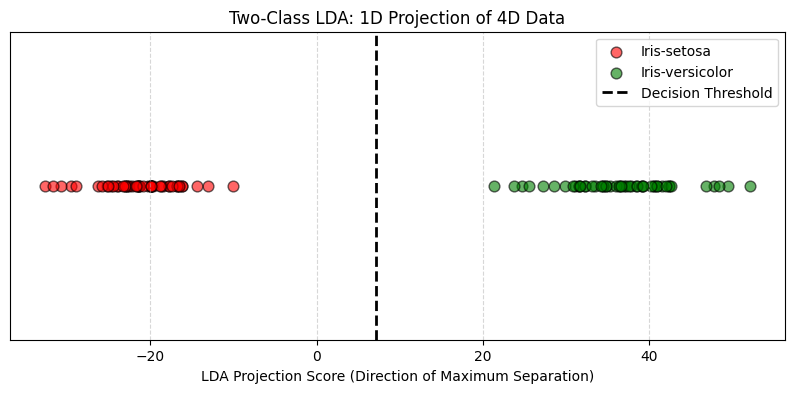

In [8]:
X_proj = X.dot(lda.w)

plt.figure(figsize=(10, 4))

plt.scatter(X_proj[y == 0], np.zeros_like(X_proj[y == 0]), 
            color='red', label='Iris-setosa', alpha=0.6, edgecolors='k', s=60)

plt.scatter(X_proj[y == 1], np.zeros_like(X_proj[y == 1]), 
            color='green', label='Iris-versicolor', alpha=0.6, edgecolors='k', s=60)

plt.axvline(lda.threshold, color='black', linestyle='--', linewidth=2, label='Decision Threshold')

plt.title('Two-Class LDA: 1D Projection of 4D Data')
plt.xlabel('LDA Projection Score (Direction of Maximum Separation)')
plt.yticks([])
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()